# This notebook performs sanity checks for all computations supported by the prior implementation. It compares resource estimates produced by the new code against the legacy code to verify consistency and identify any discrepancies. In addition, it tests the regime in which the two-body–dependent mean-field correction (i.e., the shift to the one-body term) becomes significant.

In [2]:
import warnings
import math
import numpy as np
from numpy.exceptions import ComplexWarning

# GPAW triggers harmless RuntimeWarnings (divide by zero, overflow in dot/matmul)
# on Apple Silicon due to numerical edge cases in the PAW setup and LFC phases.
# These do not affect results.
warnings.filterwarnings("ignore", category=RuntimeWarning, module="gpaw")
warnings.filterwarnings("ignore", category=RuntimeWarning, module="numpy")
warnings.filterwarnings("ignore", category=ComplexWarning)

import sys
from pathlib import Path

repo_root = Path.cwd().parent   # .../Bloch-PAW-main
sys.path.insert(0, str(repo_root))

In [3]:
from ase.build import bulk
from gpaw import GPAW, PW

from bloch_paw.extractor import PawExtractor
from bloch_paw import PawReader, OneNormCalculator, ResourceEstimator

In [4]:
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)

# Metallic hydrogen

## Different k-mesh sizes to test

In [6]:
atoms = bulk('H', 'fcc', a=3.67)  # build once; GPAW will overwrite calc each loop
Nb = 3

### LCAO mode

In [12]:
for i in range(1, 4):
    k_mesh = (i, i, i)
    k_tag = f"{i}x{i}x{i}"  # nicer filename

    # Fresh calculator each iteration
    calc = GPAW(
        mode="lcao", basis="dzp", h=0.21,
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{k_tag}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # triggers GPAW calculation and PAW setup

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
    )

    h5_path = data_dir / f"lcbo_{k_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for k mesh = {k_mesh}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for k mesh = (1, 1, 1)
One-norm λ = 109.510556
Toffoli per query:         7,405
Logical qubits:            1,118
Resource estimates for k mesh = (2, 2, 2)
One-norm λ = 768.992698
Toffoli per query:         43,792
Logical qubits:            7,083
Resource estimates for k mesh = (3, 3, 3)
One-norm λ = 3047.934812
Toffoli per query:         133,228
Logical qubits:            21,695


### PW mode

In [7]:
for i in range(3, 4):
    k_mesh = (i, i, i)
    k_tag = f"{i}x{i}x{i}"  # nicer filename

    # Fresh calculator each iteration
    calc = GPAW(mode= PW(400),
                kpts={'size': k_mesh, 'gamma': True},
                xc='PBE',
                nbands=Nb,
                symmetry={'point_group': False, 'time_reversal': False},
        txt=str(data_dir / f"gpaw_{k_tag}.txt"))
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # triggers GPAW calculation and PAW setup
    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
    )

    h5_path = data_dir / f"lcbo_{k_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for k mesh = {k_mesh}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for k mesh = (3, 3, 3)
One-norm λ = 92.205730
Toffoli per query:         71,360
Logical qubits:            10,411


## Different supercell sizes to test

In [8]:
k_mesh = (1, 1, 1)

### LCAO mode

In [15]:
for i in range(1, 3):
    cell_size = (i, i, i)
    cell_tag = f"{i}x{i}x{i}"  # nicer filename

    Nb = 5*i**3  # scale bands with system size
    atoms = bulk('H', 'fcc', a=3.67).repeat(cell_size)
    # Fresh calculator each iteration
    calc = GPAW(
        mode="lcao", basis="dzp", h=0.21,
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{cell_tag}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # triggers GPAW calculation and PAW setup
    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
    )

    h5_path = data_dir / f"lcbo_{cell_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for supercell size = {cell_size}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for supercell size = (1, 1, 1)
One-norm λ = 109.510556
Toffoli per query:         7,437
Logical qubits:            1,118
Resource estimates for supercell size = (2, 2, 2)
One-norm λ = 735.794295
Toffoli per query:         81,456
Logical qubits:            15,508


### PW mode

In [10]:
for i in range(3, 4):
    cell_size = (i, i, i)
    cell_tag = f"{i}x{i}x{i}"  # nicer filename

    Nb = 3*i**3  # scale bands with system size
    atoms = bulk('H', 'fcc', a=3.67).repeat(cell_size)
    # Fresh calculator each iteration
    calc = GPAW(mode = PW(400),
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{cell_tag}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions
    

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5
    )

    h5_path = data_dir / f"lcbo_{cell_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for supercell size = {cell_size}")
    print("=" * 60)
    print(f"Average rank (R_avg, R0): {R_avg}, {R0}")
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for supercell size = (3, 3, 3)
Average rank (R_avg, R0): 59.191877575044145, 81.0
One-norm λ = 51.724515
Toffoli per query:         181,850
Logical qubits:            36,569


## Different orbital sizes to test

### LCAO mode

In [17]:
Nb_list = [8, 9, 10]
k_mesh = (2, 2, 2)
cell_size = (2, 2, 2)
atoms = bulk('H', 'fcc', a=3.67).repeat(cell_size)

for Nb in Nb_list:
    # Fresh calculator each iteration
    calc = GPAW(
        mode="lcao", basis="dzp", h=0.21,
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{Nb}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
    )

    h5_path = data_dir / f"lcbo_{Nb}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for Nb = {Nb}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for Nb = 8
One-norm λ = 288.113087
Toffoli per query:         147,569
Logical qubits:            25,536
Resource estimates for Nb = 9
One-norm λ = 375.626992
Toffoli per query:         155,536
Logical qubits:            27,371
Resource estimates for Nb = 10
One-norm λ = 463.228448
Toffoli per query:         163,020
Logical qubits:            29,105


### PW mode

In [18]:
Nb_list = [8, 9, 10]
k_mesh = (2, 2, 2)
cell_size = (2, 2, 2)
atoms = bulk('H', 'fcc', a=3.67).repeat(cell_size)

for Nb in Nb_list:

    # Fresh calculator each iteration
    calc = GPAW(
        mode=PW(400),
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{Nb}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
    )

    h5_path = data_dir / f"lcbo_{Nb}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for Nb = {Nb}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for Nb = 8
One-norm λ = 111.815961
Toffoli per query:         157,118
Logical qubits:            27,045
Resource estimates for Nb = 9
One-norm λ = 110693.975551
Toffoli per query:         169,890
Logical qubits:            29,799
Resource estimates for Nb = 10
One-norm λ = 169.899252
Toffoli per query:         180,902
Logical qubits:            32,199


## More sanity checks

In [19]:
k_mesh = (1, 1, 1)

cell_size = (2, 2, 2)
cell_tag = f"{2}x{2}x{2}"  # nicer filename

Nb = 5*8  #scale bands with system size
atoms = bulk('H', 'fcc', a=3.67).repeat(cell_size)
# Fresh calculator each iteration
calc = GPAW(mode = PW(400),
    kpts={"size": k_mesh, "gamma": True},
    xc="PBE", nbands=Nb,
    symmetry={"point_group": False, "time_reversal": False},
    txt=str(data_dir / f"gpaw_{cell_tag}.txt"),  # optional: per-run log
)
atoms.calc = calc

calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions


# Export Bloch-PAW ingredients
extractor = PawExtractor(
    calc, nbands=Nb,
    thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5
)

rho = extractor.pair_density_matrix()
C_matrix = extractor.C_tensor()
D_matrix = extractor.D_matrix()
h_matrix = extractor.one_body_integrals_kdiag()

In [20]:
print(f"Pair density matrix: {rho[0][2][0][4][1][3]}")
print(f"One body integral: {h_matrix[0][2][0][39]}")
print(f"PAW C-tensor: {C_matrix[0][2][0][4][1]}")
print(f"PAW D-tensor: {D_matrix[0][0][0][0][1][2][3]}")

Pair density matrix: [ 0.00754863+0.j  0.01360471+0.j  0.00226312+0.j -0.00920925+0.j
 -0.00377054+0.j -0.02119742+0.j -0.01383608+0.j  0.01274676+0.j
 -0.04359952+0.j -0.00278666+0.j -0.04201655+0.j -0.01474161+0.j
 -0.01489248+0.j -0.00258269+0.j -0.0011968 +0.j -0.00251928+0.j
  0.00546062+0.j  0.00012988+0.j  0.00185163+0.j  0.02612026+0.j
  0.00703218+0.j  0.04131094+0.j  0.02071077+0.j  0.0267592 +0.j]
One body integral: 0j
PAW C-tensor: 0.0
PAW D-tensor: (8.308983256668676e-18+0j)


In [21]:
k_mesh = (2, 2, 2)

cell_size = (1, 1, 1)
k_tag = f"{2}x{2}x{2}"  # nicer filename

Nb = 5*8  #scale bands with system size
atoms = bulk('H', 'fcc', a=3.67).repeat(cell_size)
# Fresh calculator each iteration
calc = GPAW(mode = PW(400),
    kpts={"size": k_mesh, "gamma": True},
    xc="PBE", nbands=Nb,
    symmetry={"point_group": False, "time_reversal": False},
    txt=str(data_dir / f"gpaw_{k_tag}.txt"),  # optional: per-run log
)
atoms.calc = calc

calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions


# Export Bloch-PAW ingredients
extractor = PawExtractor(
    calc, nbands=Nb,
    thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5
)

rho = extractor.pair_density_matrix()
C_matrix = extractor.C_tensor()
D_matrix = extractor.D_matrix()
h_matrix = extractor.one_body_integrals_kdiag()

In [22]:
print(f"Pair density matrix: {rho[0][2][0][4][1][3][6]}")
print(f"One body integral: {h_matrix[0][2][0][39]}")
print(f"PAW C-tensor: {C_matrix[0][2][0][4][1]}")
print(f"PAW D-tensor: {D_matrix[0][0][0][0][1][2][3]}")

Pair density matrix: (-0.005799913346208112-0.00773623391550333j)
One body integral: (7.192868262811958e-16-0.0008546828576028017j)
PAW C-tensor: 0.0
PAW D-tensor: 0j


In [ ]:
cell_size = (1, 1, 1)

for i in range(1, 4):
    k_mesh = (i, i, i)
    k_tag = f"{i}x{i}x{i}"  # nicer filename

    # Fresh calculator each iteration
    calc = GPAW(
        mode="lcao", basis="dzp", h=0.21,
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{k_tag}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    
    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
    )

    h5_path = data_dir / f"lcbo_{k_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=True)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for k mesh = {k_mesh}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

ValueError: Too many bands for LCAO calculation: 40 bands and only 5 atomic orbitals!

# Diamond

## LCAO

### k-points

In [41]:
Nb = 8
h_cut = 0.30
atoms = bulk('C', 'diamond', a=3.567)

In [ ]:
for i in range(1, 3):
    k_mesh = (i, i, i)
    k_tag = f"{i}x{i}x{i}"  # nicer filename

    # Fresh calculator each iteration
    calc = GPAW(
        mode="lcao", basis="dzp", h=h_cut,
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{k_tag}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions
    

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
    )

    h5_path = data_dir / f"lcbo_{k_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False, write_two_body_split=False)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for k mesh = {k_mesh}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for k mesh = (1, 1, 1)
One-norm λ = 138.065603
Toffoli per query:         8,677
Logical qubits:            1,312
Resource estimates for k mesh = (2, 2, 2)
One-norm λ = 1039.068379
Toffoli per query:         49,892
Logical qubits:            8,551


### Supercell

In [26]:
k_mesh = (1, 1, 1)

In [27]:
for i in range(1, 3):
    cell_size = (i, i, i)
    cell_tag = f"{i}x{i}x{i}"  # nicer filename

    Nb = 8*i**3  # scale bands with system size
    atoms = bulk('C', 'diamond', a=3.567).repeat(cell_size)
    # Fresh calculator each iteration
    calc = GPAW(
        mode="lcao", basis="dzp", h=h_cut,
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{cell_tag}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions
    

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
    )

    h5_path = data_dir / f"lcbo_{cell_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for supercell size = {cell_size}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for supercell size = (1, 1, 1)
One-norm λ = 138.065603
Toffoli per query:         8,677
Logical qubits:            1,312
Resource estimates for supercell size = (2, 2, 2)
One-norm λ = 932.474105
Toffoli per query:         80,374
Logical qubits:            14,609


## PW

### k-points

In [45]:
cell_size = (1, 1, 1)
for i in range(3, 4):
    k_mesh = (i, i, i)
    k_tag = f"{i}x{i}x{i}"  # nicer filename
    Nb = 17  # scale bands with system size
    atoms = bulk('C', 'diamond', a=3.567).repeat(cell_size)
    # Fresh calculator each iteration
    calc = GPAW(mode= PW(500),
                kpts={'size': k_mesh, 'gamma': True},
                xc='PBE',
                nbands=Nb,
                symmetry={'point_group': False, 'time_reversal': False},
        txt=str(data_dir / f"gpaw_{k_tag}.txt"))
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions
    

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-9, thr_kappa=1e-9,
    )

    h5_path = data_dir / f"lcbo_{k_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=True)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-6, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for k mesh = {k_mesh}")
    print("=" * 60)
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

Resource estimates for k mesh = (3, 3, 3)
One-norm λ = 30062.257051
Toffoli per query:         536,288
Logical qubits:            103,785


### Supercell

In [ ]:
k_mesh = (1, 1, 1)
for i in range(3, 4):
    cell_size = (i, i, i)
    cell_tag = f"{i}x{i}x{i}"  # nicer filename

    Nb = 17*i**3  # scale bands with system size
    atoms = bulk('C', 'diamond', a=3.567).repeat(cell_size)
    # Fresh calculator each iteration
    calc = GPAW(mode = PW(500),
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{cell_tag}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    
    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-9, thr_kappa=1e-9
    )

    h5_path = data_dir / f"lcbo_{cell_tag}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=True)

    # Read + resource estimation
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-6, sv_floor=1e-12, scale_floor=1e-12
        )
        lam = one_norm_calc.lambda_one_norm()
        R_avg, R0 = one_norm_calc.compute_average_rank()

        eps_chem = 27e-3
        eps_qpe = eps_chem / 5

        est = ResourceEstimator.from_hdf5(str(h5_path))
        toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
        qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
        iters = math.ceil(math.pi * lam / eps_qpe)

    

    print("=" * 60)
    print(f"Resource estimates for supercell size = {cell_size}")
    print("=" * 60)
    print(f"Average rank (R_avg, R0): {R_avg}, {R0}")
    print(f"One-norm λ = {lam:.6f}")
    print(f"Toffoli per query:         {toffolis:,}")
    print(f"Logical qubits:            {qubits:,}")
    print("=" * 60)

: 

# Nickel

In [30]:
Nb = 10
atoms = bulk('Ni', 'fcc', a=3.52)

## k-space

In [31]:
k_mesh = (4, 4, 4)
k_tag = f"{2}x{2}x{2}"  # nicer filename

# Fresh calculator each iteration
calc = GPAW(mode= PW(400),
            kpts={'size': k_mesh, 'gamma': True},
            xc='PBE',
            nbands=Nb,
            symmetry={'point_group': False, 'time_reversal': False},
    txt=str(data_dir / f"gpaw_{k_tag}.txt"))
atoms.calc = calc

calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions

# Max number of plane waves (G-vectors) over k-points (and spins)
pd = calc.wfs.pd
print(r"$N_{\text{pw}} =$", pd.ngmax)

# Total number of grid points in the unit cell
gd = calc.density.gd
print(r"$N_{\text{grid}} =$", int(np.prod(gd.N_c)))

# Export Bloch-PAW ingredients
extractor = PawExtractor(
    calc, nbands=Nb,
    thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5,
)

h5_path = data_dir / f"pw_{k_tag}.h5"
extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

# Read + resource estimation
reader = PawReader(str(h5_path))
with reader:
    inputs = reader.to_calculator_inputs(lazy=True)

    one_norm_calc = OneNormCalculator(
        **inputs, thr_rank=3e-5, sv_floor=1e-12, scale_floor=1e-12
    )
    lam = one_norm_calc.lambda_one_norm()
    R_avg, R0 = one_norm_calc.compute_average_rank()

    eps_chem = 27e-3
    eps_qpe = eps_chem / 5

    est = ResourceEstimator.from_hdf5(str(h5_path))
    toffolis = est.toffoli_count_per_be(Rl=R_avg, R0=R0)
    qubits = est.total_qubits(Rl=R_avg, R0=R0, lam=lam, eps_qpe=eps_qpe)
    iters = math.ceil(math.pi * lam / eps_qpe)



print("=" * 60)
print(f"Resource estimates for k mesh = {k_mesh}")
print("=" * 60)
print(f"One-norm λ = {lam:.6f}")
print(f"Toffoli per query:         {toffolis:,}")
print(f"Logical qubits:            {qubits:,}")
print("=" * 60)

$N_{\text{pw}} =$ 210
$N_{\text{grid}} =$ 1728
Resource estimates for k mesh = (4, 4, 4)
One-norm λ = 22568.026691
Toffoli per query:         672,506
Logical qubits:            121,765


# Exclusion of $\kappa$

In [32]:
k_mesh = (2, 2, 2)

cell_size = (1, 1, 1)
k_mesh_tag = f"{2}x{2}x{2}"  # nicer filename

Nb = 5  #scale bands with system size
atoms = bulk('H', 'fcc', a=3.67).repeat(cell_size)
# Fresh calculator each iteration
calc = GPAW(mode = 'lcao', basis='dzp', h=0.30,
    kpts={"size": k_mesh, "gamma": True},
    xc="PBE", nbands=Nb,
    symmetry={"point_group": False, "time_reversal": False},
    txt=str(data_dir / f"gpaw_{k_mesh_tag}.txt"),  # optional: per-run log
)
atoms.calc = calc

calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions


# Export Bloch-PAW ingredients
extractor = PawExtractor(
    calc, nbands=Nb,
    thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-5, thr_kappa=1e-5
)

rho = extractor.pair_density_matrix()
C_matrix = extractor.C_tensor()
D_matrix = extractor.D_matrix()
h_matrix = extractor.one_body_integrals_kdiag()
kappa_matrix = extractor.two_body_integrals()

In [33]:
kappa_matrix[0][0][0][0][0]

array([0.00058726+0.j, 0.00211654+0.j, 0.00153471+0.j, 0.00153474+0.j,
       0.00153474+0.j])

## Metallic Hydrogen

In [39]:
Nb_list = list(range(1, 20)) 
cell_size = (1, 1, 1)
k_mesh_list = [(1,1,1), (2, 2, 2)] 
atoms = bulk('H', 'fcc', a=3.67).repeat(cell_size)
lam_dict = {}
lam_diff = {}

for i,k_mesh in enumerate(k_mesh_list):
    lam_dict[i] = []
    lam_diff[i] = []
    for Nb in Nb_list:
        # Fresh calculator each iteration
        calc = GPAW(
            mode=PW(400),
            kpts={"size": k_mesh, "gamma": True},
            xc="PBE", nbands=Nb,
            symmetry={"point_group": False, "time_reversal": False},
            txt=str(data_dir / f"gpaw_{Nb}.txt"),  # optional: per-run log
        )
        atoms.calc = calc

        calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions

        # Export Bloch-PAW ingredients
        extractor = PawExtractor(
            calc, nbands=Nb,
            thr_rho=1.0e-16, thr_D=1.0e-19, thr_C=1.0e-7, thr_h=1e-9, thr_kappa=1e-19,
        )

        h5_path = data_dir / f"lcbo_{Nb}.h5"
        extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

        # Read
        reader = PawReader(str(h5_path))
        with reader:
            inputs = reader.to_calculator_inputs(lazy=True)

            one_norm_calc = OneNormCalculator(
                **inputs, thr_rank=3e-9, sv_floor=1e-12, scale_floor=1e-12
            )
            lam_1 = one_norm_calc.lambda_one_norm()

        extractor.export_hdf5(filepath=str(h5_path))


        reader = PawReader(str(h5_path))
        with reader:
            inputs = reader.to_calculator_inputs(lazy=True)

            one_norm_calc = OneNormCalculator(
                **inputs, thr_rank=3e-6, sv_floor=1e-12, scale_floor=1e-12
            )
            lam_2 = one_norm_calc.lambda_one_norm()
        lam_dict[i].append(lam_2)
        lam_diff[i].append(lam_2 - lam_1)

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

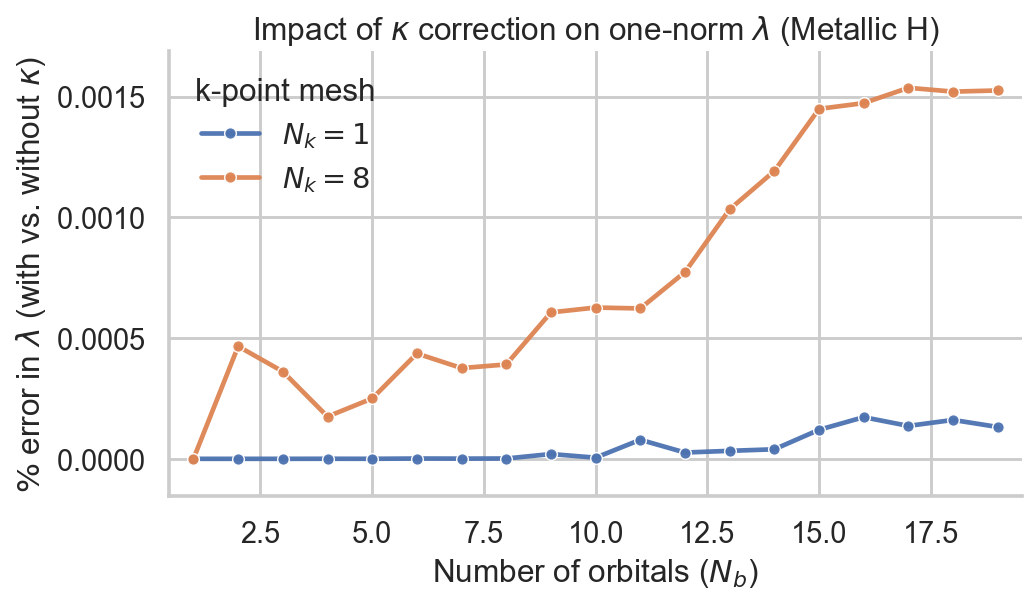

In [40]:
# --- style ---
sns.set_theme(style="whitegrid", context="talk", font_scale=0.9)

fig, ax = plt.subplots(figsize=(7.8, 4.6), dpi=140)

# map your i -> Nk label
Nk_map = {0: 1, 1: 8}

for i in [0, 1]:
    lam = np.asarray(lam_dict[i], dtype=float)
    dlam = np.asarray(lam_diff[i], dtype=float)
    y = np.abs(dlam) / lam * 100.0

    sns.lineplot(
        x=Nb_list, y=y,
        ax=ax,
        marker="o",
        markersize=6,
        linewidth=2.4,
        alpha=0.95,
        label=rf"$N_k={Nk_map[i]}$",
    )

# labels/titles
ax.set_xlabel(r"Number of orbitals ($N_b$)")
ax.set_ylabel(r"$\%$ error in $\lambda$ (with vs. without $\kappa$)")
ax.set_title(r"Impact of $\kappa$ correction on one-norm $\lambda$ (Metallic H)")

# legend + polish
ax.legend(title="k-point mesh", frameon=False, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# (Percent values usually don't need sci notation; keep if you want)
# ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

ax.margins(x=0.03, y=0.10)
fig.tight_layout()
plt.show()

## Diamond

In [37]:
Nb_list = list(range(10, 20)) 
cell_size = (1, 1, 1)
k_mesh = (2, 2, 2) 
atoms = bulk('C', 'diamond', a=3.567).repeat(cell_size)
lam_list = []
lam_diff = []

for Nb in Nb_list:
    # Fresh calculator each iteration
    calc = GPAW(
        mode=PW(350),
        kpts={"size": k_mesh, "gamma": True},
        xc="PBE", nbands=Nb,
        symmetry={"point_group": False, "time_reversal": False},
        txt=str(data_dir / f"gpaw_{Nb}.txt"),  # optional: per-run log
    )
    atoms.calc = calc

    calc.get_potential_energy(atoms)  # run SCF to initialize wavefunctions

    # Export Bloch-PAW ingredients
    extractor = PawExtractor(
        calc, nbands=Nb,
        thr_rho=1.0e-19, thr_D=1.0e-19, thr_C=1.0e-17, thr_h=1e-9, thr_kappa=1e-19,
    )

    h5_path = data_dir / f"lcbo_{Nb}.h5"
    extractor.export_hdf5(filepath=str(h5_path), write_two_body=False)

    # Read
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-9, sv_floor=1e-12, scale_floor=1e-12
        )
        lam_1 = one_norm_calc.lambda_one_norm()

    extractor.export_hdf5(filepath=str(h5_path), write_two_body=True)
    
    
    reader = PawReader(str(h5_path))
    with reader:
        inputs = reader.to_calculator_inputs(lazy=True)

        one_norm_calc = OneNormCalculator(
            **inputs, thr_rank=3e-9, sv_floor=1e-12, scale_floor=1e-12
        )
        lam_2 = one_norm_calc.lambda_one_norm()
    lam_list.append(lam_1)
    lam_diff.append(lam_2 - lam_1)

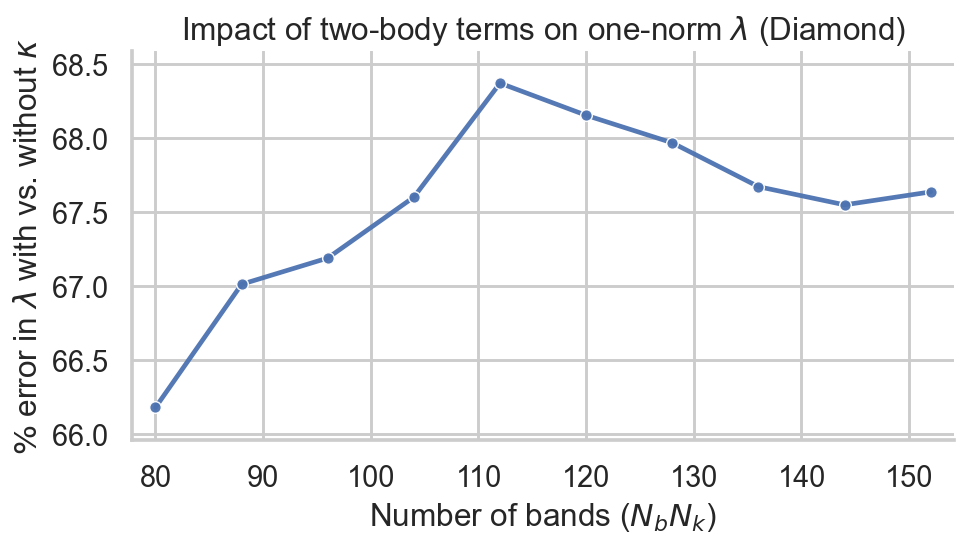

In [38]:
# --- style ---
sns.set_theme(
    style="whitegrid",
    context="talk",   # scales fonts/lines for presentations; use "paper" for smaller
    font_scale=0.9
)

fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=140)

y = (np.abs(np.array(lam_diff)) / np.array(lam_list))*100

sns.lineplot(
    x=k_mesh[0]**3*np.array(Nb_list), y=y,
    ax=ax,
    marker="o",
    markersize=6,
    linewidth=2.4,
    alpha=0.95,
)
    
# labels/titles
ax.set_xlabel(r"Number of bands ($N_b N_k$)")
ax.set_ylabel(r"$\%$ error in $\lambda$ with vs. without $\kappa$")
ax.set_title(r"Impact of two-body terms on one-norm $\lambda$ (Diamond)")

# polish
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# If y is small, scientific notation tends to look cleaner:
ax.ticklabel_format(axis="y", style="sci", scilimits=(-2, 2))
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))

ax.margins(x=0.03, y=0.10)
fig.tight_layout()
plt.show()